## Часть 1. EDA и Preprocessing.
Датасет German Credit Risk, масштабирование и зачем оно.

In [1]:
debug = 0

In [2]:
# Загрузка требуемых библиотек
import os
import umap
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

In [3]:
# Общие полезные функции

def log(message):
    if debug == 1:
        # %Y-%m-%d — дата, %H:%M:%S — время
        timestamp = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
        print(f"[DEBUG] {timestamp} {message}")

log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")


In [4]:
# Загрузка датасета
path = kagglehub.dataset_download("uciml/german-credit")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\oevlannikov\.cache\kagglehub\datasets\uciml\german-credit\versions\1


In [5]:
# Читаем CSV
files = os.listdir(path)
log("Files: " + str(files))

df_bank  = pd.read_csv(os.path.join(path, files[0]), index_col=0) # используем индекс kaggle

rows, cols = df_bank.shape
log(f"Размер данных: {rows} строк и {cols} колонок")

In [6]:
df_bank.head()  # шапка данных

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [7]:
df_bank.info()  # типы данных, количество не-null значений

df_bank.describe(include='all') #базовая статисктика

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 78.1+ KB


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8
top,NaN,male,NaN,own,little,little,NaN,NaN,car
freq,NaN,690,NaN,713,603,274,NaN,NaN,337
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN


Age колеблется от 19 до 75 лет, Credit amount от 250 до 18424.

Масштабирование потребуется далее для кластеризации, поскольку если модель начнет считать расстояние между клиентами без масштабирования, разница в 5000 марок кредита полностью «затопит» разницу в 30 лет возраста. Алгоритм будет думать, что клиенты 20 и 50 лет с одинаковым кредитом — это «близнецы», а клиенты одного возраста с разницей в кредите — абсолютно разные люди. 

Масштабирование (например, StandardScaler) приводит все признаки к единой шкале (где среднее = 0, а стандартное отклонение = 1), давая каждому признаку равный голос при формировании кластеров.

В Saving accounts и Checking account есть дырки, которые нужно будет заполнить.

In [8]:
# Из чего состоят для приведения в будущем
for col in df_bank.columns:
    log(f"Столбец {col}: {df_bank[col].unique()}\n")

In [9]:
# Выводим уникальные значения категориальных признаков для анализа стратегии кодирования
cat_cols = df_bank.select_dtypes(include=['object']).columns.tolist()
print("\nУникальные значения категориальных признаков:")
for col in cat_cols:
    print(f"{col}: {df_bank[col].unique()}")


Уникальные значения категориальных признаков:
Sex: ['male' 'female']
Housing: ['own' 'free' 'rent']
Saving accounts: [nan 'little' 'quite rich' 'rich' 'moderate']
Checking account: ['little' 'moderate' nan 'rich']
Purpose: ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']


## Обработка пропусков

In [10]:
# Заполнение пустот текстом НД
df_bank['Saving accounts'] = df_bank['Saving accounts'].fillna('unknown')
df_bank['Checking account'] = df_bank['Checking account'].fillna('unknown')

log(df_bank.isna().sum())   # может остались

## Кодирование признаков в числовые

In [11]:
# Бинарный признак (Sex) -> в 0/1
df_bank['Sex'] = df_bank['Sex'].map({'male': 1, 'female': 0})

# Порядковый текстовый признак (Saving accounts) -> в числа вручную, сохраняя логику возрастания
# 'unknown' поставим в начало как отсутствие информации
savings_map = {'unknown': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4}
df_bank['Saving accounts'] = df_bank['Saving accounts'].map(savings_map)

# Номинальные признаки (Housing, Purpose) -> One-Hot Encoding (создаем дамми-переменные)
# При кластеризации One-Hot предпочтительнее, чем LabelEncoder, чтобы не вводить ложный порядок
df_bank = pd.get_dummies(df_bank, columns=['Housing', 'Purpose', 'Checking account'], drop_first=True, dtype=int)

if (df_bank.dtypes == 'int64').all():
    log("Все признаки успешно переведены в числовой формат!")
else:
    log("Что-то не сработало. ДФ:")
    df_bank.info()  # типы данных, количество не-null значений

## Масштабирование с помощью StandardScaler

In [12]:
# Применяем стандартное масштабирование (Z-score)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_bank)
scaled_df = pd.DataFrame(scaled, columns=df_bank.columns)

print("Данные приведены к одному масштабу.")
print(f"Итоговая матрица признаков для кластеризации: {scaled_df.shape}")
scaled_df.head()


Данные приведены к одному масштабу.
Итоговая матрица признаков для кластеризации: (1000, 18)


,Age,Sex,Job,Saving accounts,Credit amount,Duration,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Checking account_moderate,Checking account_rich,Checking account_unknown
0,2.766456,0.670280,0.146949,-1.231393,-0.745131,-1.236478,0.634448,-0.466933,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208,-0.606621,-0.259299,-0.806328
1,-1.191404,-1.491914,0.146949,-0.196609,0.949817,2.248194,0.634448,-0.466933,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208,1.648476,-0.259299,-0.806328
2,1.183312,0.670280,-1.383771,-0.196609,-0.416562,-0.738668,0.634448,-0.466933,-0.712949,-0.110208,3.993639,-0.470108,-0.623610,-0.149983,-0.110208,-0.606621,-0.259299,1.240190
3,0.831502,0.670280,0.146949,-0.196609,1.634247,1.750384,-1.576173,-0.466933,-0.712949,-0.110208,-0.250398,2.127172,-0.623610,-0.149983,-0.110208,-0.606621,-0.259299,-0.806328
4,1.535122,0.670280,0.146949,-0.196609,0.566664,0.256953,-1.576173,-0.466933,1.402626,-0.110208,-0.250398,-0.470108,-0.623610,-0.149983,-0.110208,-0.606621,-0.259299,-0.806328


## Часть 2. Моделирование.

Сначала подберём оптимальное количество кластеров для каждого метода при помощи Elbow method и Silhouette plot

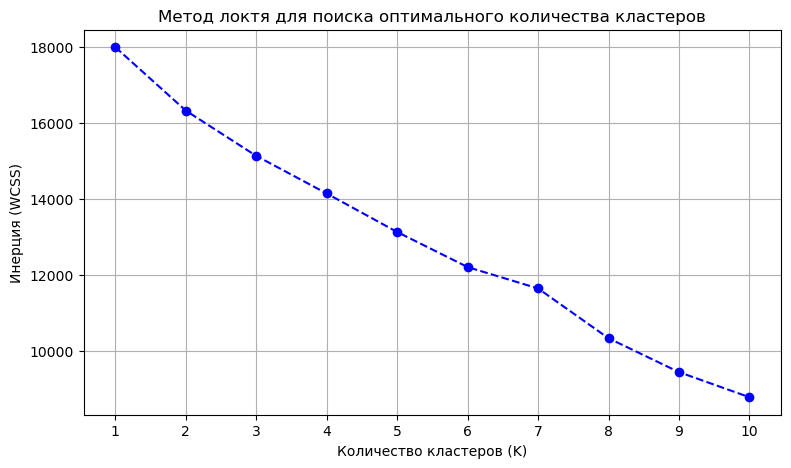

In [13]:
# 1) Elbow Method

# Инициализируем список для сохранения значений инерции
inertia = []
K_range = range(1, 11)

# Проверяем количество кластеров от 1 до 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

# Строим график метода локтя
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Метод локтя для поиска оптимального количества кластеров')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Чёткий излом графика на 7.

Кластеров: 2 | Средний силуэт: 0.1463
Кластеров: 3 | Средний силуэт: 0.1376
Кластеров: 4 | Средний силуэт: 0.1136
Кластеров: 5 | Средний силуэт: 0.1461
Кластеров: 6 | Средний силуэт: 0.1715
Кластеров: 7 | Средний силуэт: 0.1572


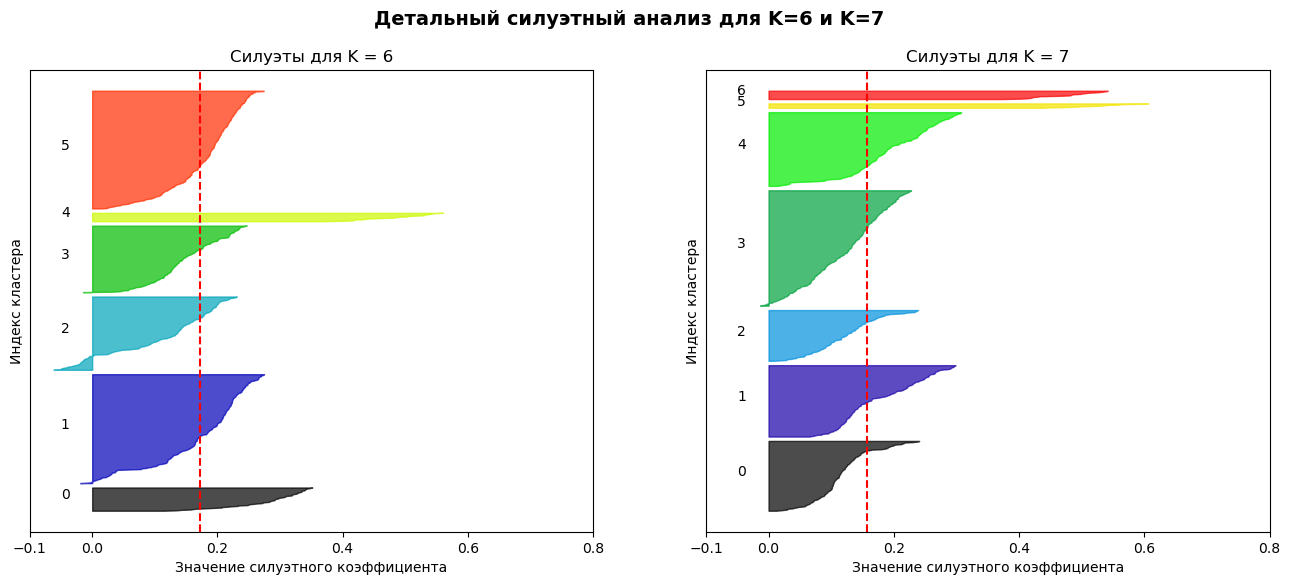

In [14]:
# Silhouette Plot


# 1. Поиск глобального максимума средней метрики силуэта
scores = []
K_range_sil = range(2, 8) # Силуэт нельзя посчитать для 1 кластера

for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    scores.append(score)
    print(f"Кластеров: {k} | Средний силуэт: {score:.4f}")

# 2. Построение детального Silhouette Plot для конкретных K (например, 3 и 4)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for n_clusters, ax in zip([6, 7], [ax1, ax2]):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(scaled_df)
    silhouette_avg = silhouette_score(scaled_df, cluster_labels)
    sample_silhouette_values = silhouette_samples(scaled_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 

    ax.set_title(f"Силуэты для K = {n_clusters}")
    ax.set_xlabel("Значение силуэтного коэффициента")
    ax.set_ylabel("Индекс кластера")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--") # Средняя линия
    ax.set_yticks([])  
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8])

plt.suptitle("Детальный силуэтный анализ для K=6 и K=7", fontsize=14, fontweight='bold')
plt.show()

Выбранные для отображения графики с К6 и К7 показывают наиболее стабильные кластеры, практически без хвостов слева. Наиболее правильным выглядит К6, поскольку соседний график, судя по всему отображает разбиение и так тонкой прослойки на две супер-специфические.

Теперь запишем каждому клиенту метку кластера и посмотрим на их средние портреты в оригинальном ДФ, чтобы описать человеческим языком, а так же, воспользуемся различными вариантами сжатия признакового пространства (PCA, UMAP, tSNE) и визуализируем результаты кластеризации на двумерной плоскости

In [15]:
# 1. Обучаем финальную модель на 6 кластеров
optimal_k = 6
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Записываем метки кластеров прямо в исходный(!) датафрейм для анализа
df_bank['Cluster'] = kmeans_final.fit_predict(scaled_df)

# 2. Считаем средние профили по главным числовым признакам
numeric_profile = df_bank.groupby('Cluster')[['Age', 'Credit amount', 'Duration']].mean()
print("ФИНАНСОВО-ВОЗРАСТНОЙ ПРОФИЛЬ КЛАСТЕРОВ (СРЕДНИЕ ЗНАЧЕНИЯ):")
print(numeric_profile)
print("\n" + "="*70 + "\n")

# 3. Посмотрим, какие цели кредита (Purpose) преобладают в группах
print("РАСПРЕДЕЛЕНИЕ ЦЕЛЕЙ КРЕДИТА ПО КЛАСТЕРАМ (В %):")

# Находим все колонки, которые начинаются с 'Purpose_'
purpose_cols = [col for col in df_bank.columns if col.startswith('Purpose_')]

# Считаем среднее значение по каждому One-Hot столбцу внутри кластера.
# Так как значения там 0 или 1, среднее будет в точности равно доле (проценту) этой цели в кластере
purpose_profile = df_bank.groupby('Cluster')[purpose_cols].mean() * 100

# Для красоты переименуем колонки, убрав приставку 'Purpose_'
purpose_profile.columns = [col.replace('Purpose_', '') for col in purpose_profile.columns]
print(purpose_profile.round(1))
print("\n" + "="*70 + "\n")


ФИНАНСОВО-ВОЗРАСТНОЙ ПРОФИЛЬ КЛАСТЕРОВ (СРЕДНИЕ ЗНАЧЕНИЯ):
               Age  Credit amount   Duration
Cluster                                     
0        38.288136    2879.203390  19.677966
1        34.930403    2456.937729  20.087912
2        34.309783    3773.451087  22.358696
3        30.419162    3153.191617  19.419162
4        38.545455    2728.090909  19.090909
5        39.016949    3897.372881  21.969492


РАСПРЕДЕЛЕНИЕ ЦЕЛЕЙ КРЕДИТА ПО КЛАСТЕРАМ (В %):
          car  domestic appliances  education  furniture/equipment  radio/TV  \
Cluster                                                                        
0         0.0                  0.0      100.0                  0.0       0.0   
1         0.0                  3.7        0.0                  0.0      88.6   
2         0.0                  0.0        0.0                 72.3       0.0   
3        37.7                  1.2        0.0                 28.7      22.8   
4         0.0                  0.0        0.0      

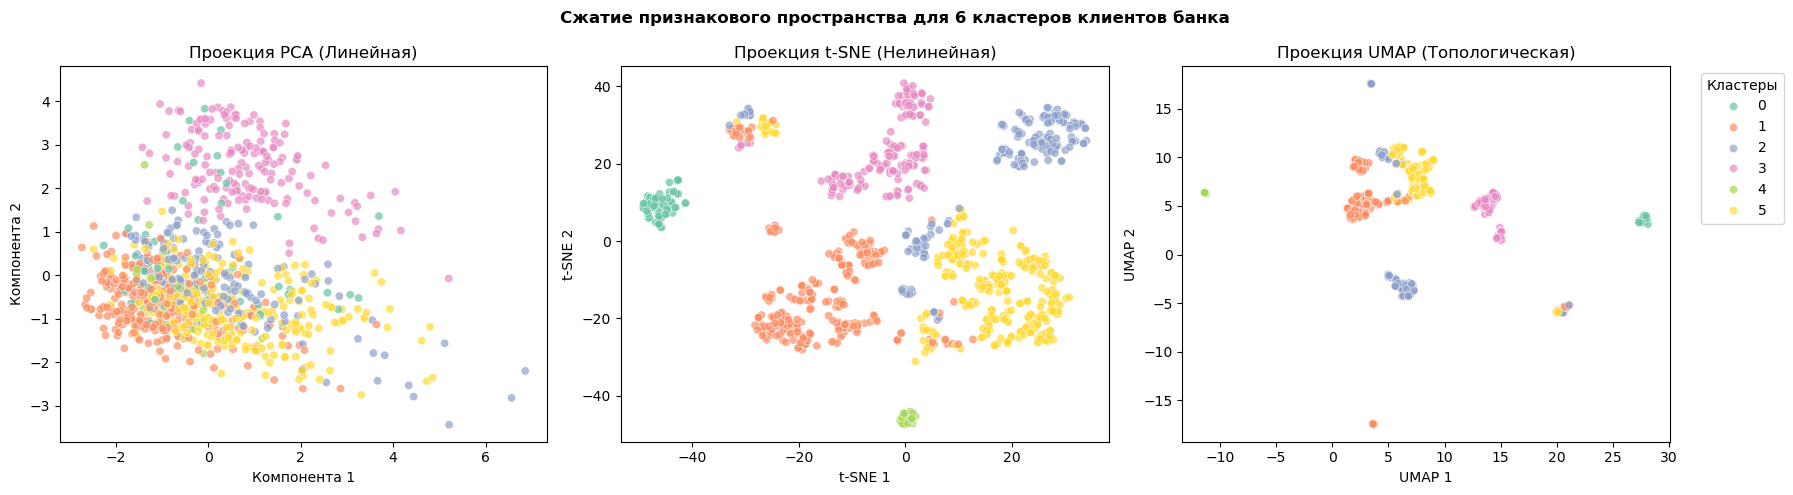

In [16]:
## Сжатие пространства признаков для отображения на плоскости

labels = kmeans_final.labels_

# А. Метод PCA
log("Запуск PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled_df)
log("PCA завершён.")

# Б. Метод t-SNE (распараллеленный через n_jobs=-1)
log("Запуск t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=1)
X_tsne = tsne.fit_transform(scaled_df)
log("t-SNE завершён.")

# В. Метод UMAP
log("Запуск UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=1)
X_umap = reducer.fit_transform(scaled_df)
n_plots = 3
log("UMAP завершён.")


# Строим графики сравнения проекций
log("Запуск снижения размерности для визуализации...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Явно задаем 3 графика, так как UMAP посчитан
palette = sns.color_palette("Set2", n_colors=optimal_k)

# Отрисовка PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette=palette, alpha=0.7, ax=axes[0])
axes[0].set_title('Проекция PCA (Линейная)')
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend().remove() # Убираем лишние внутренние легенды

# Отрисовка t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette=palette, alpha=0.7, ax=axes[1])
axes[1].set_title('Проекция t-SNE (Нелинейная)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend().remove()

# Отрисовка UMAP
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels, palette=palette, alpha=0.7, ax=axes[2])
axes[2].set_title('Проекция UMAP (Топологическая)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
# Выносим единую красивую легенду для всех графиков в самый правый край
axes[2].legend(title="Кластеры", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Сжатие признакового пространства для 6 кластеров клиентов банка', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

log("Визуализация завершена.")

- PCA слева показал сплошное облако, где кластеры сильно перемешаны и наслоены друг на друга.
- t-SNE в центре разделил кластеры отлично. Все данные разделены на чёткие острова, в особенности 0 и 2 находятся по краям -- значит у этих клиентов есть ярко выраженные признаки
- UMAP собрал кластеры в плотные компактные группы, а пограничные точки вытянул в изолированные узлы. Здесь видно на примере кластеров 1 и 5, что профили похожи, но K-Means смог найти границу всё равно.

## Часть 3. Интерпретация.

In [17]:
# Настраиваем pandas, чтобы он выводил все столбцы таблицы на экран
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 1. Основные финансово-демографические метрики (Средние значения)
base_metrics = ['Age', 'Sex', 'Job', 'Credit amount', 'Duration', 'Saving accounts']
profile_base = df_bank.groupby('Cluster')[base_metrics].mean()

# Переводим доли в проценты для наглядности
profile_base['Sex (Male %)'] = (profile_base['Sex'] * 100).round(1)
profile_base.drop(columns=['Sex'], inplace=True)

print("Основные финансово-демографические метрики (Средние значения):")
print(profile_base.round(1))
print("\n" + "-"*70 + "\n")

Основные финансово-демографические метрики (Средние значения):
          Age  Job  Credit amount  Duration  Saving accounts  Sex (Male %)
Cluster                                                                   
0        38.3  1.8         2879.2      19.7              1.0          59.3
1        34.9  1.8         2456.9      20.1              1.2          70.0
2        34.3  2.0         3773.5      22.4              1.2          74.5
3        30.4  1.9         3153.2      19.4              1.2          46.1
4        38.5  1.5         2728.1      19.1              1.4          77.3
5        39.0  2.0         3897.4      22.0              1.1          79.0

----------------------------------------------------------------------



In [18]:
# 2. Цели кредита (Purpose) — выводим топ-3 преобладающих целей для каждого кластера
purpose_cols = [col for col in df_bank.columns if col.startswith('Purpose_')]
profile_purpose = df_bank.groupby('Cluster')[purpose_cols].mean() * 100
profile_purpose.columns = [col.replace('Purpose_', '') for col in profile_purpose.columns]

print("Цели кредита (Доля В % внутри кластера):")
# Для красоты выведем транспонированную таблицу, так её легче читать глазами
print(profile_purpose.T.round(1))
print("\n" + "-"*70 + "\n")

Цели кредита (Доля В % внутри кластера):
Cluster                  0     1     2     3      4     5
car                    0.0   0.0   0.0  37.7    0.0  92.9
domestic appliances    0.0   3.7   0.0   1.2    0.0   0.0
education            100.0   0.0   0.0   0.0    0.0   0.0
furniture/equipment    0.0   0.0  72.3  28.7    0.0   0.0
radio/TV               0.0  88.6   0.0  22.8    0.0   0.0
repairs                0.0   0.0   0.0   0.0  100.0   0.0
vacation/others        0.0   0.0   6.5   0.0    0.0   0.0

----------------------------------------------------------------------



In [19]:
# 3. Тип жилья (Housing)
housing_cols = [col for col in df_bank.columns if col.startswith('Housing_')]
profile_housing = df_bank.groupby('Cluster')[housing_cols].mean() * 100
profile_housing.columns = [col.replace('Housing_', '') for col in profile_housing.columns]
print("Тип жилья (Доля В % внутри кластера):")
print(profile_housing.T.round(1))

Тип жилья (Доля В % внутри кластера):
Cluster     0     1     2      3     4     5
own      57.6  94.5  90.2    0.0  77.3  80.7
rent     16.9   0.0   0.0  100.0   9.1   0.0


Интерпретируя полученную статистику, можно сделать вывод о том что клиенты банка делятся на чёткие категории по кластерам:
0. Студенты. 100% кредитов на образование
1. Домохозяйки. 88.6% на ТВ, при этом у них есть своё жильё
2. Обустройство. 72.3% кредитов на мебель, 90% владеют жильём
3. Молодые независимые. 100% снимают жильё, больше всего женщин (53.9%) и цель кредита либо автомобиль либо мебель
4. Домохозяева. В основном мужчины зрелого возраста, с накоплениями, берут маленькие суммы на ремонт
5. Автовладельцы. 92.9% кредитов на машину, самый возрастной и богатый кластер, в основном мужчины которые имеют жильё

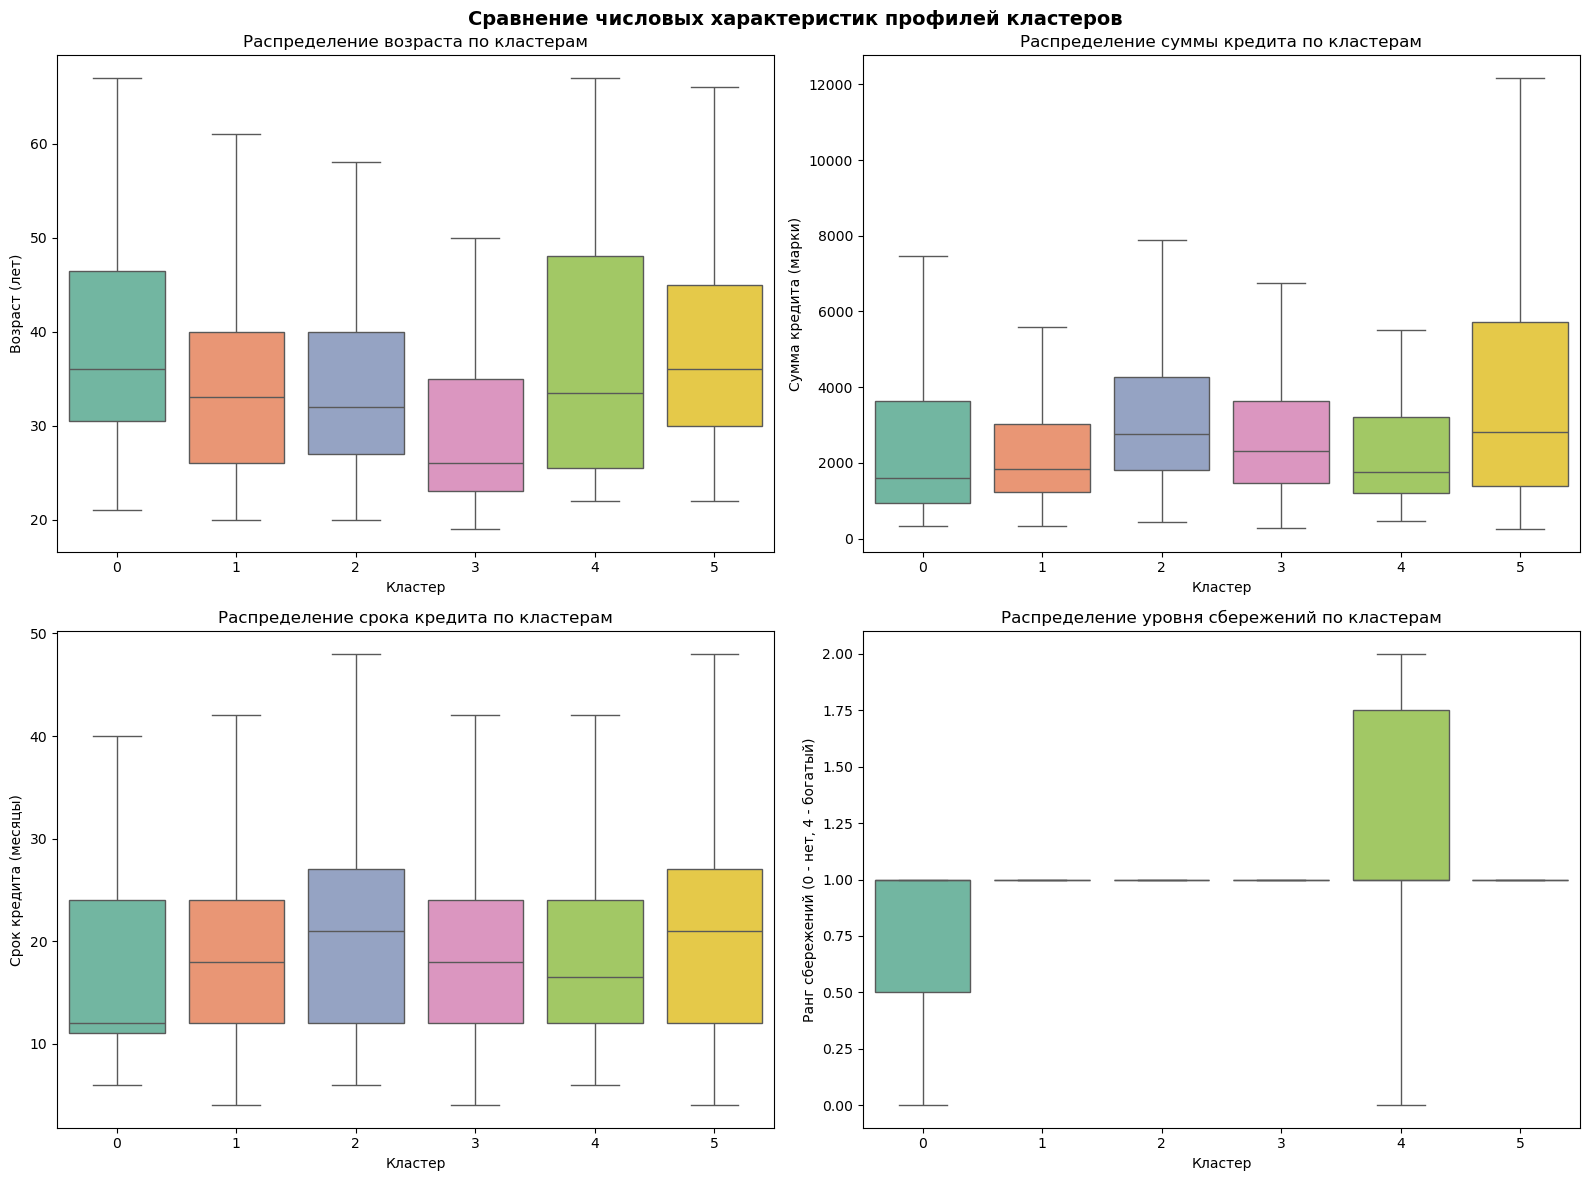

In [20]:
# Отображение boxplot-ов для каждого признака, сгруппировав значения по кластерам

# Настраиваем сетку графиков 2х2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = sns.color_palette("Set2", n_colors=optimal_k)

# 1. График для Возраста (Age)
sns.boxplot(data=df_bank, x='Cluster', y='Age', hue='Cluster', palette=palette, ax=axes[0, 0], legend=False, showfliers=False)
axes[0, 0].set_title('Распределение возраста по кластерам')
axes[0, 0].set_xlabel('Кластер')
axes[0, 0].set_ylabel('Возраст (лет)')

# 2. График для Суммы кредита (Credit amount)
sns.boxplot(data=df_bank, x='Cluster', y='Credit amount', hue='Cluster', palette=palette, ax=axes[0, 1], legend=False, showfliers=False)
axes[0, 1].set_title('Распределение суммы кредита по кластерам')
axes[0, 1].set_xlabel('Кластер')
axes[0, 1].set_ylabel('Сумма кредита (марки)')

# 3. График для Срока кредита (Duration)
sns.boxplot(data=df_bank, x='Cluster', y='Duration', hue='Cluster', palette=palette, ax=axes[1, 0], legend=False, showfliers=False)
axes[1, 0].set_title('Распределение срока кредита по кластерам')
axes[1, 0].set_xlabel('Кластер')
axes[1, 0].set_ylabel('Срок кредита (месяцы)')

# 4. График для Сбережений (Saving accounts)
sns.boxplot(data=df_bank, x='Cluster', y='Saving accounts', hue='Cluster', palette=palette, ax=axes[1, 1], legend=False, showfliers=False)
axes[1, 1].set_title('Распределение уровня сбережений по кластерам')
axes[1, 1].set_xlabel('Кластер')
axes[1, 1].set_ylabel('Ранг сбережений (0 - нет, 4 - богатый)')

plt.suptitle('Сравнение числовых характеристик профилей кластеров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# По каким признакам заметно наибольшее отличие кластеров друг от друга? Можно ли их интерпретировать?
- Credit amount (Сумма кредита) и Duration (Срок) — Максимальное отличие
Эти два признака сильнее всего разделили клиентов по финансовым аппетитам и долговой нагрузке.
Кластер 5 (машины) имеет самый высокий и широкий ящик. Его верхний «ус» уходит к отметке в 12000, а кластер 1 (бытовая техника) самый узкий и низкий говорит что клиенты берут маленькие заёмы.

- Age (Возраст) — Умеренное, но четкое отличие
Возраст помог алгоритму четко отделить молодую, только встающую на ноги аудиторию от социально стабильных, зрелых клиентов. Явно выделяется на фоне остальных кластер 3. Весь его ящик сдвинут вниз — медиана находится на уровне 26–27 лет, а верхний «ус» заканчивается там, где у других кластеров (например, 0, 4 и 5) медиана только начинается. Кластера 0, 4, 5 -- зрелые, закрепившиеся в жизни клиенты среднего возраста.

- Saving accounts (Сбережения) — Слабое отличие
Этот признак оказался наименее информативным для глобального разделения, так как большинство заемщиков в принципе имеют схожий (невысокий) уровень накоплений, независимо от того, на что они берут кредит. У кластеров 1, 2, 3 и 5 ящики превратились в одни плоские линии на отметке 1.0, но у кластера 4 есть визуальное отображение бережливых домашних мастеров по ремонту.

## Итоги
Алгоритм выделил группы не по случайному шуму, а по фундаментальным жизненным маркерам (молодые арендаторы без сбережений против зрелых домовладельцев с накоплениями). Каждый кластер теперь — это готовый, понятный бизнес-сегмент для маркетинга банка.